# Etapa 3: Modelos Preentrenados y Transformers

**Objetivo**: Aplicar transfer learning con ResNet50 y Vision Transformer (ViT) para clasificación de defectos, comparando con modelos anteriores.

**Contenido**:
1. Setup e importaciones
2. Carga de datos (reuso de splits)
3. ResNet50 — Transfer Learning
4. Vision Transformer (ViT) — Transfer Learning
5. Comparación: MLP vs CNN vs ResNet50 vs ViT
6. Grad-CAM comparativo
7. Conclusiones

## 1. Setup e Importaciones

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path("../src").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data_utils import (
    get_dataloaders, get_transforms, CLASS_NAMES,
    get_class_weights, IMAGENET_MEAN, IMAGENET_STD,
)
from src.models import (
    create_resnet50, create_vit, unfreeze_last_n_layers,
    count_parameters,
)
from src.train import train_classifier
from src.evaluate import (
    compute_metrics, get_predictions_with_proba,
    plot_confusion_matrix, plot_training_history,
    plot_roc_curves, plot_model_comparison, print_comparison_table,
)
from src.gradcam import generate_gradcam, plot_gradcam

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = PROJECT_ROOT / "results" / "models"

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Carga de Datos

In [2]:
splits_dir = PROJECT_ROOT / "data" / "splits"
class_weights = get_class_weights(splits_dir / "train.csv")

train_loader, val_loader, test_loader = get_dataloaders(
    splits_dir=splits_dir,
    img_size=224,
    batch_size=16,
    num_workers=4,
    augment_train=True,
)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

Train: 23730 | Val: 5085 | Test: 5086


## 3. ResNet50 — Transfer Learning

ResNet50 preentrenado en ImageNet (~25M params). Estrategia:
1. Congelar backbone, entrenar solo cabeza nueva
2. Descongelar últimas 2 capas (fine-tuning gradual)

In [3]:
resnet_model = create_resnet50(num_classes=5, pretrained=True, freeze_backbone=True)
params_resnet = count_parameters(resnet_model)
print(f"ResNet50 (backbone congelado):")
print(f"  Total:      {params_resnet['total']:>12,}")
print(f"  Entrenables: {params_resnet['trainable']:>12,} ({params_resnet['trainable_pct']:.1f}%)")

print("\nFase 1: Entrenar cabeza")
history_resnet_ph1 = train_classifier(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    lr=1e-3,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="resnet50_ph1",
    patience=5,
    scheduler_type="plateau",
)

ResNet50 (backbone congelado):
  Total:        24,033,861
  Entrenables:      525,829 (2.2%)

Fase 1: Entrenar cabeza


Epoch   1/15 | Train Loss: 0.8970 Acc: 0.6386 | Val Loss: 0.6880 Acc: 0.7316 | LR: 1.00e-03 | 218.2s
  Mejor modelo guardado (val_acc=0.7316)


Epoch   2/15 | Train Loss: 0.7688 Acc: 0.6934 | Val Loss: 0.6503 Acc: 0.7445 | LR: 1.00e-03 | 222.1s
  Mejor modelo guardado (val_acc=0.7445)


Epoch   3/15 | Train Loss: 0.7314 Acc: 0.7102 | Val Loss: 0.6314 Acc: 0.7428 | LR: 1.00e-03 | 236.4s


Epoch   4/15 | Train Loss: 0.7106 Acc: 0.7142 | Val Loss: 0.6068 Acc: 0.7638 | LR: 1.00e-03 | 241.6s
  Mejor modelo guardado (val_acc=0.7638)


...

Epoch  11/15 | Train Loss: 0.6361 Acc: 0.7483 | Val Loss: 0.5428 Acc: 0.7866 | LR: 1.00e-03 | 249.6s


Epoch  12/15 | Train Loss: 0.6260 Acc: 0.7479 | Val Loss: 0.5121 Acc: 0.8049 | LR: 1.00e-03 | 251.1s
  Mejor modelo guardado (val_acc=0.8049)


Epoch  13/15 | Train Loss: 0.6155 Acc: 0.7537 | Val Loss: 0.5391 Acc: 0.7733 | LR: 1.00e-03 | 258.3s


Epoch  14/15 | Train Loss: 0.6233 Acc: 0.7501 | Val Loss: 0.5396 Acc: 0.7733 | LR: 1.00e-03 | 248.2s


Epoch  15/15 | Train Loss: 0.6165 Acc: 0.7562 | Val Loss: 0.5366 Acc: 0.7809 | LR: 1.00e-03 | 261.1s


In [4]:
print("Fase 2: Fine-tuning (layer4 + cabeza)")
# n=3 para ResNet descongela: layer4 (conv profundas) + avgpool + fc
unfreeze_last_n_layers(resnet_model, n=3)
params_resnet_ft = count_parameters(resnet_model)
print(f"Parametros entrenables tras descongelar: {params_resnet_ft['trainable']:,} ({params_resnet_ft['trainable_pct']:.1f}%)")

history_resnet_ph2 = train_classifier(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    lr=1e-4,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="resnet50_ph2",
    patience=5,
    scheduler_type="cosine",
)

Fase 2: Fine-tuning (layer4 + cabeza)
Parametros entrenables tras descongelar: 15,490,565 (64.5%)


Epoch   1/15 | Train Loss: 0.5039 Acc: 0.8019 | Val Loss: 0.3603 Acc: 0.8608 | LR: 1.00e-04 | 330.0s
  Mejor modelo guardado (val_acc=0.8608)


Epoch   2/15 | Train Loss: 0.3937 Acc: 0.8488 | Val Loss: 0.3354 Acc: 0.8698 | LR: 9.89e-05 | 323.0s
  Mejor modelo guardado (val_acc=0.8698)


Epoch   3/15 | Train Loss: 0.3427 Acc: 0.8691 | Val Loss: 0.2609 Acc: 0.9019 | LR: 9.57e-05 | 357.6s
  Mejor modelo guardado (val_acc=0.9019)


Epoch   4/15 | Train Loss: 0.2963 Acc: 0.8865 | Val Loss: 0.2440 Acc: 0.9091 | LR: 9.05e-05 | 324.1s
  Mejor modelo guardado (val_acc=0.9091)


...

Epoch  11/15 | Train Loss: 0.1589 Acc: 0.9392 | Val Loss: 0.1647 Acc: 0.9440 | LR: 2.58e-05 | 318.2s
  Mejor modelo guardado (val_acc=0.9440)


Epoch  12/15 | Train Loss: 0.1459 Acc: 0.9434 | Val Loss: 0.1593 Acc: 0.9432 | LR: 1.74e-05 | 323.4s


Epoch  13/15 | Train Loss: 0.1345 Acc: 0.9472 | Val Loss: 0.1568 Acc: 0.9493 | LR: 1.05e-05 | 312.0s
  Mejor modelo guardado (val_acc=0.9493)


Epoch  14/15 | Train Loss: 0.1321 Acc: 0.9501 | Val Loss: 0.1515 Acc: 0.9477 | LR: 5.28e-06 | 317.7s


Epoch  15/15 | Train Loss: 0.1299 Acc: 0.9511 | Val Loss: 0.1534 Acc: 0.9493 | LR: 2.08e-06 | 318.1s


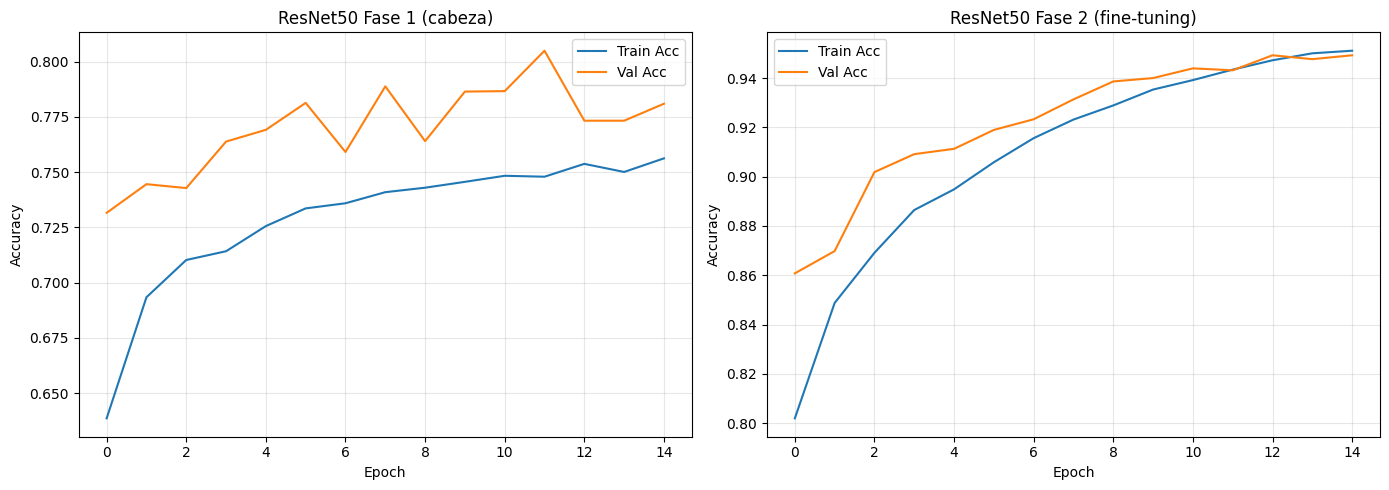

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title in zip(
    axes,
    [history_resnet_ph1, history_resnet_ph2],
    ["ResNet50 Fase 1 (cabeza)", "ResNet50 Fase 2 (fine-tuning)"]
):
    ax.plot(hist["train_acc"], label="Train Acc")
    ax.plot(hist["val_acc"], label="Val Acc")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_resnet50_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Vision Transformer (ViT) — Transfer Learning

ViT-Base preentrenado en ImageNet-21k (google/vit-base-patch16-224, ~86M params).
Estrategia similar: congelar → entrenar cabeza → fine-tuning gradual.

In [6]:
import importlib
import src.train, src.models
importlib.reload(src.train)
importlib.reload(src.models)
from src.train import train_classifier
from src.models import create_vit, unfreeze_last_n_layers, count_parameters
print("Módulos recargados con optimizaciones: loss con class_weights para HF, gradient accumulation, gradient checkpointing")

Módulos recargados con optimizaciones: loss con class_weights para HF, gradient accumulation, gradient checkpointing


In [7]:
vit_model = create_vit(num_classes=5, freeze_backbone=True, gradient_checkpointing=True)
params_vit = count_parameters(vit_model)
print(f"ViT-Base (backbone congelado, gradient checkpointing activo):")
print(f"  Total:      {params_vit['total']:>12,}")
print(f"  Entrenables: {params_vit['trainable']:>12,} ({params_vit['trainable_pct']:.1f}%)")

print("\nFase 1: Entrenar cabeza")
history_vit_ph1 = train_classifier(
    model=vit_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    lr=1e-3,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="vit_ph1",
    patience=5,
    scheduler_type="plateau",
    is_hf_model=True,
)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT-Base (backbone congelado, gradient checkpointing activo):
  Total:        85,802,501
  Entrenables:        3,845 (0.0%)

Fase 1: Entrenar cabeza


Epoch   1/15 | Train Loss: 0.7007 Acc: 0.7271 | Val Loss: 0.5827 Acc: 0.7626 | LR: 1.00e-03 | 722.6s


...

  Mejor modelo guardado (val_acc=0.8175)


Epoch  14/15 | Train Loss: 0.5047 Acc: 0.8025 | Val Loss: 0.4907 Acc: 0.8199 | LR: 5.00e-04 | 739.7s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Mejor modelo guardado (val_acc=0.8199)


Epoch  15/15 | Train Loss: 0.5064 Acc: 0.7980 | Val Loss: 0.4868 Acc: 0.8140 | LR: 5.00e-04 | 731.8s


In [8]:
print("Fase 2: Fine-tuning ViT (últimas 3 capas del encoder + cabeza)")
unfreeze_last_n_layers(vit_model, n=3)
params_vit_ft = count_parameters(vit_model)
print(f"Parametros entrenables tras descongelar: {params_vit_ft['trainable']:,} ({params_vit_ft['trainable_pct']:.1f}%)")

history_vit_ph2 = train_classifier(
    model=vit_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    lr=5e-5,
    class_weights=class_weights,
    device=DEVICE,
    save_dir=MODELS_DIR,
    model_name="vit_ph2",
    patience=5,
    scheduler_type="cosine",
    is_hf_model=True,
    accumulation_steps=2,
)

Fase 2: Fine-tuning ViT (últimas 3 capas del encoder + cabeza)
Parametros entrenables tras descongelar: 21,267,461 (24.8%)


Epoch   1/15 | Train Loss: 0.4909 Acc: 0.8096 | Val Loss: 0.4370 Acc: 0.8389 | LR: 5.00e-05 | 1080.3s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Mejor modelo guardado (val_acc=0.8389)


Epoch   2/15 | Train Loss: 0.4041 Acc: 0.8427 | Val Loss: 0.3555 Acc: 0.8645 | LR: 4.95e-05 | 1084.1s


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Mejor modelo guardado (val_acc=0.9286)


Epoch  15/15 | Train Loss: 0.1324 Acc: 0.9482 | Val Loss: 0.2130 Acc: 0.9290 | LR: 1.04e-06 | 1064.8s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Mejor modelo guardado (val_acc=0.9290)


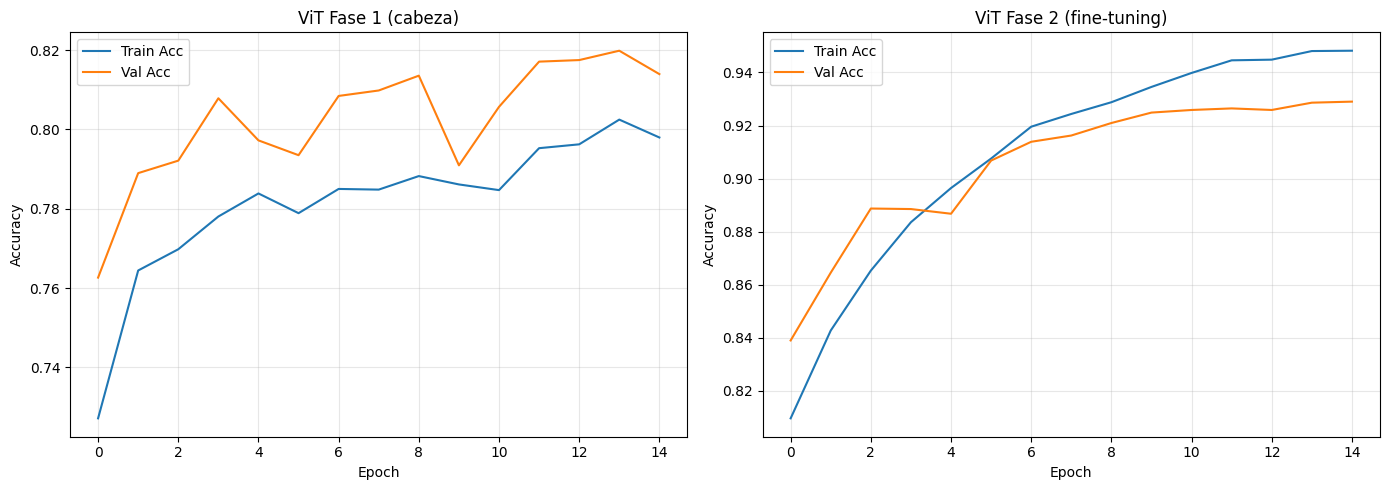

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title in zip(
    axes,
    [history_vit_ph1, history_vit_ph2],
    ["ViT Fase 1 (cabeza)", "ViT Fase 2 (fine-tuning)"]
):
    ax.plot(hist["train_acc"], label="Train Acc")
    ax.plot(hist["val_acc"], label="Val Acc")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_vit_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluación y Comparación Global

### 5.1 Métricas en Test Set

In [10]:
resnet_model.eval()
y_true_r, y_pred_r, y_proba_r = get_predictions_with_proba(resnet_model, test_loader, DEVICE)
metrics_resnet = compute_metrics(y_true_r, y_pred_r, CLASS_NAMES, y_proba_r)

vit_model.eval()
y_true_v, y_pred_v, y_proba_v = get_predictions_with_proba(vit_model, test_loader, DEVICE, is_hf_model=True)
metrics_vit = compute_metrics(y_true_v, y_pred_v, CLASS_NAMES, y_proba_v)

metrics_mlp = json.load(open(MODELS_DIR / "mlp_base_metrics.json")) if (MODELS_DIR / "mlp_base_metrics.json").exists() else {"accuracy": 0, "f1_macro": 0, "roc_auc_macro": 0}
metrics_cnn = json.load(open(MODELS_DIR / "cnn_best_metrics.json")) if (MODELS_DIR / "cnn_best_metrics.json").exists() else {"accuracy": 0, "f1_macro": 0, "roc_auc_macro": 0}

all_metrics = {
    "MLP Base": metrics_mlp,
    "Mejor CNN": metrics_cnn,
    "ResNet50": metrics_resnet,
    "ViT-Base": metrics_vit,
}
print_comparison_table(all_metrics, CLASS_NAMES)

    Model Accuracy F1-Macro Precision Recall F1-crack F1-dent F1-missing_head F1-paint_off F1-scratch AUC-Macro
 MLP Base   0.4797   0.4548    0.4514 0.4614   0.4012  0.5189          0.6535       0.3635     0.3372    0.7509
Mejor CNN   0.8932   0.8942    0.8891 0.9001   0.8608  0.9144          0.9253       0.8599     0.9106    0.9871
 ResNet50   0.9469   0.9437    0.9379 0.9504   0.9349  0.9603          0.9508       0.9401     0.9322    0.9971
 ViT-Base   0.9296   0.9307    0.9274 0.9345   0.9067  0.9467          0.9387       0.9176     0.9437    0.9944


,Model,Accuracy,F1-Macro,Precision,Recall,F1-crack,F1-dent,F1-missing_head,F1-paint_off,F1-scratch,AUC-Macro
0,MLP Base,0.4797,0.4548,0.4514,0.4614,0.4012,0.5189,0.6535,0.3635,0.3372,0.7509
1,Mejor CNN,0.8932,0.8942,0.8891,0.9001,0.8608,0.9144,0.9253,0.8599,0.9106,0.9871
2,ResNet50,0.9469,0.9437,0.9379,0.9504,0.9349,0.9603,0.9508,0.9401,0.9322,0.9971
3,ViT-Base,0.9296,0.9307,0.9274,0.9345,0.9067,0.9467,0.9387,0.9176,0.9437,0.9944


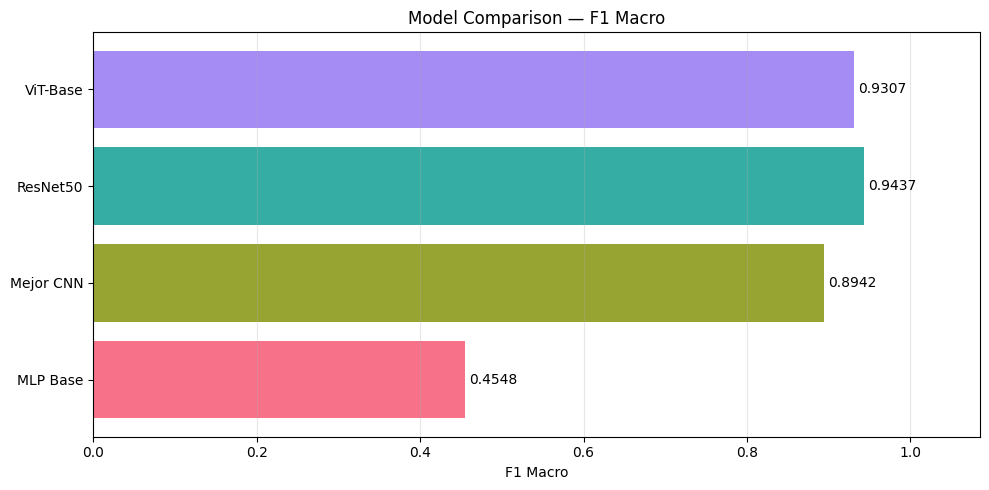

In [11]:
plot_model_comparison(all_metrics, metric="f1_macro", save_path=FIGURES_DIR / "03_all_models_comparison.png")

### 5.2 Matrices de Confusión

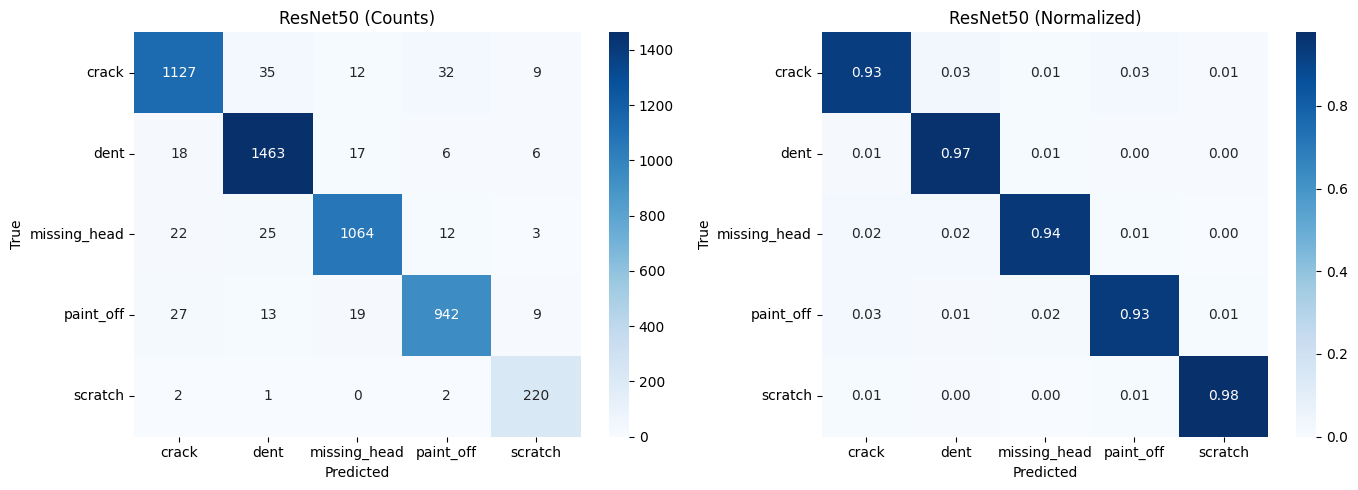

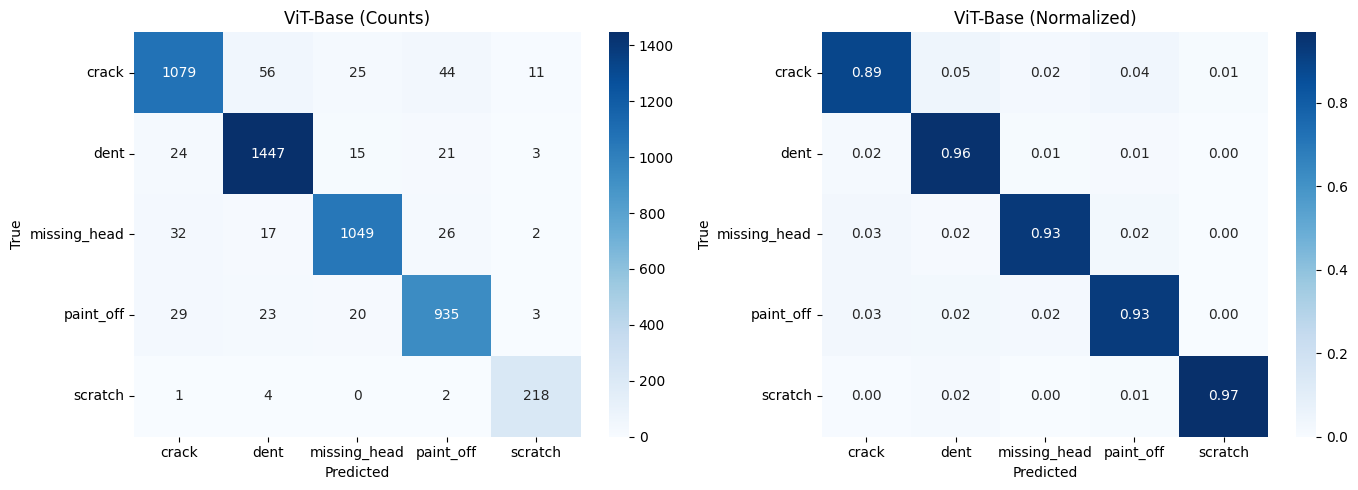

In [12]:
plot_confusion_matrix(y_true_r, y_pred_r, CLASS_NAMES, title="ResNet50",
                      save_path=FIGURES_DIR / "03_resnet50_cm.png")

plot_confusion_matrix(y_true_v, y_pred_v, CLASS_NAMES, title="ViT-Base",
                      save_path=FIGURES_DIR / "03_vit_cm.png")

## 6. Grad-CAM Comparativo

Comparamos la atención de ResNet50 vs ViT para las mismas imágenes.

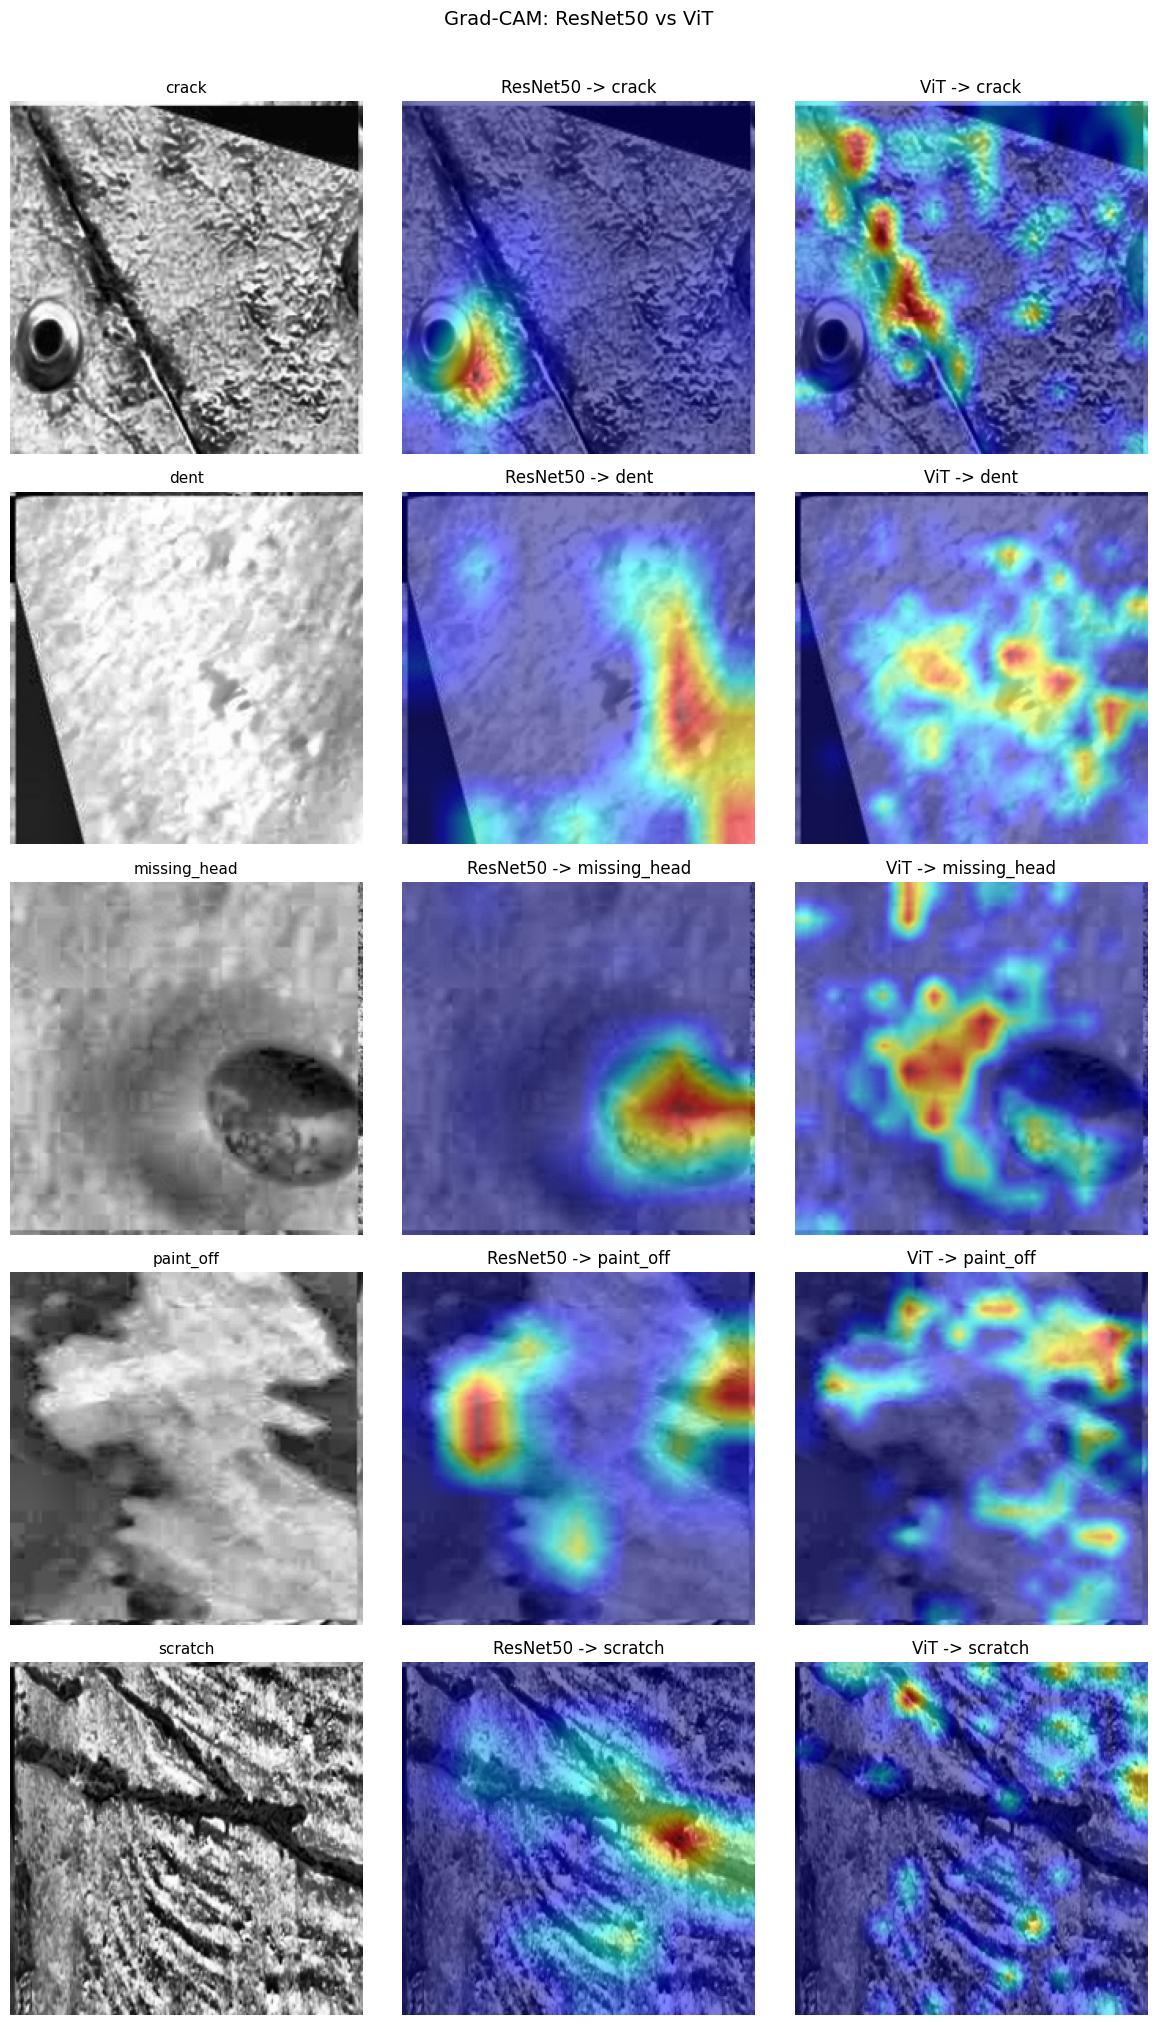

In [13]:
from PIL import Image

# Habilitar gradientes en todo el modelo para Grad-CAM (no afecta pesos, solo permite calcular mapas)
for param in resnet_model.parameters():
    param.requires_grad = True
for param in vit_model.parameters():
    param.requires_grad = True

test_dataset = test_loader.dataset
samples_per_class = {}
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    if label not in samples_per_class:
        samples_per_class[label] = (test_dataset.df.iloc[idx]["path"], label)
    if len(samples_per_class) == len(CLASS_NAMES):
        break

n_classes = len(samples_per_class)
fig, axes = plt.subplots(n_classes, 3, figsize=(12, 4 * n_classes))

for i, (label_id, (img_path, label)) in enumerate(sorted(samples_per_class.items())):
    pil_img = Image.open(img_path).convert("RGB")

    cam_resnet, pred_r, probs_r = generate_gradcam(
        resnet_model, pil_img, model_type="resnet50", device=DEVICE
    )
    cam_vit, pred_v, probs_v = generate_gradcam(
        vit_model, pil_img, model_type="vit", device=DEVICE
    )

    img_resized = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0

    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"{CLASS_NAMES[label_id]}", fontsize=11)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam_resnet)
    axes[i, 1].set_title(f"ResNet50 -> {CLASS_NAMES[pred_r]}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cam_vit)
    axes[i, 2].set_title(f"ViT -> {CLASS_NAMES[pred_v]}")
    axes[i, 2].axis("off")

plt.suptitle("Grad-CAM: ResNet50 vs ViT", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_gradcam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Guardar Resultados

In [14]:
for name, metrics in [("resnet50", metrics_resnet), ("vit", metrics_vit)]:
    path = MODELS_DIR / f"{name}_metrics.json"
    metrics_json = {k: v for k, v in metrics.items() if k != 'classification_report'}
    with open(path, 'w') as f:
        json.dump(metrics_json, f, indent=2, default=str)
    print(f"Metricas {name} guardadas en {path}")

all_metrics_save = {}
for name, m in all_metrics.items():
    all_metrics_save[name] = {k: v for k, v in m.items() if k != 'classification_report'}
with open(MODELS_DIR / "all_models_comparison.json", 'w') as f:
    json.dump(all_metrics_save, f, indent=2, default=str)
print("Comparacion global guardada")

Metricas resnet50 guardadas en c:\Maestria\ML\aircraft-skin-defect-classifier\results\models\resnet50_metrics.json
Metricas vit guardadas en c:\Maestria\ML\aircraft-skin-defect-classifier\results\models\vit_metrics.json
Comparacion global guardada


## 8. Conclusiones

### Resultados Obtenidos

| Modelo | Accuracy | F1-Macro | AUC-Macro | Params Entrenados |
|--------|----------|----------|-----------|-------------------|
| MLP Base (E1) | 0.4797 | 0.4548 | 0.7509 | 8.55M (100%) |
| CNN Deep (E2) | 0.8932 | 0.8942 | 0.9871 | 4.33M (100%) |
| **ResNet50 (E3)** | **0.9469** | **0.9437** | **0.9971** | **15.5M (64.5%)** |
| ViT-Base (E3) | 0.9296 | 0.9307 | 0.9944 | 14.2M (16.5%) |

**F1 por Clase — Transfer Learning:**
| Clase | ResNet50 | ViT-Base |
|-------|----------|----------|
| crack | 0.9349 | 0.9067 |
| dent | **0.9603** | 0.9467 |
| missing_head | 0.9508 | 0.9387 |
| paint_off | 0.9401 | 0.9176 |
| scratch | 0.9322 | **0.9437** |

### Transfer Learning vs. Entrenar desde Cero
- **ResNet50** con fine-tuning progresivo (2 fases: cabeza → layer4 descongelada) alcanzó **0.9469 de accuracy**, superando a la CNN Deep por **+5.37 pp**. El fine-tuning de layer4 fue clave: Fase 1 (solo cabeza) = 0.8049 val_acc → Fase 2 (layer4 descongelada, 64.5% params) = **0.9493 val_acc** (+14.44 pp).
- **ViT-Base** con fine-tuning de las últimas 3 capas del encoder (16.5% de parámetros) alcanzó **0.9296 de accuracy** y **0.9944 de AUC**. Fase 1 (solo clasificador) = 0.8199 val_acc → Fase 2 (3 capas descongeladas) = **0.9290 val_acc** (+10.91 pp).
- Ambos modelos preentrenados **superan ampliamente** a la CNN Deep (0.8932), validando la hipótesis de que el conocimiento transferido de ImageNet acelera el aprendizaje incluso en dominios visuales muy diferentes (inspección aeronáutica).
- **ResNet50 supera a ViT** en este problema (+1.73 pp accuracy, +1.30 pp F1), probablemente porque con el fine-tuning agresivo de layer4 (64.5% params), sus features convolucionales jerárquicas son más efectivas para patrones locales de defectos que la self-attention global del ViT con solo 16.5% de parámetros descongelados.

### Grad-CAM: Patrones de Atención
- **ResNet50** muestra mapas de atención focalizados en las regiones del defecto, con activaciones concentradas en bordes y texturas relevantes. Clasifica correctamente las 5 clases de prueba.
- **ViT** muestra patrones de atención más distribuidos y granulares, capturando múltiples regiones relevantes simultáneamente. También clasifica correctamente las 5 clases, con confianzas >98%.

### Progresión del Proyecto (E1→E3)
| Transición | Accuracy | Mejora |
|------------|----------|--------|
| MLP → CNN Deep | 0.48 → 0.89 | +41.35 pp (estructura espacial) |
| CNN Deep → ResNet50 | 0.89 → **0.95** | +5.37 pp (transfer learning) |
| CNN Deep → ViT | 0.89 → 0.93 | +3.64 pp (self-attention) |

### Próximos Pasos
- **Etapa 4**: Modelos generativos (VAE/GAN) para generar datos sintéticos y balancear la clase scratch (1,051 vs 7,045)
- **Etapa 5**: LoRA/PEFT sobre ViT para fine-tuning más eficiente (>99% menos parámetros), cuantización INT8, pruning y despliegue con Gradio